# Heart Disease Prediction System using Feature-Optimized Machine Learning

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.feature_selection import RFE

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc

In [2]:
df = pd.read_csv("heart.csv")

df.head()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0


In [3]:
df.shape

(1190, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   int64  
 1   sex                  1190 non-null   int64  
 2   chest pain type      1190 non-null   int64  
 3   resting bp s         1190 non-null   int64  
 4   cholesterol          1190 non-null   int64  
 5   fasting blood sugar  1190 non-null   int64  
 6   resting ecg          1190 non-null   int64  
 7   max heart rate       1190 non-null   int64  
 8   exercise angina      1190 non-null   int64  
 9   oldpeak              1190 non-null   float64
 10  ST slope             1190 non-null   int64  
 11  target               1190 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 111.7 KB


In [5]:
df.describe()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
count,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000
mean,53.720168,0.763866,3.232773,132.153782,210.363866,0.213445,0.698319,139.732773,0.387395,0.922773,1.624370,0.528571
std,9.358203,0.424884,0.935480,18.368823,101.420489,0.409912,0.870359,25.517636,0.487360,1.086337,0.610459,0.499393
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,188.000000,0.000000,0.000000,121.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,229.000000,0.000000,0.000000,140.500000,0.000000,0.600000,2.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,269.750000,0.000000,2.000000,160.000000,1.000000,1.600000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,1.000000


In [6]:
df.isnull().sum()

,0
age,0
sex,0
chest pain type,0
resting bp s,0
cholesterol,0
fasting blood sugar,0
resting ecg,0
max heart rate,0
exercise angina,0
oldpeak,0


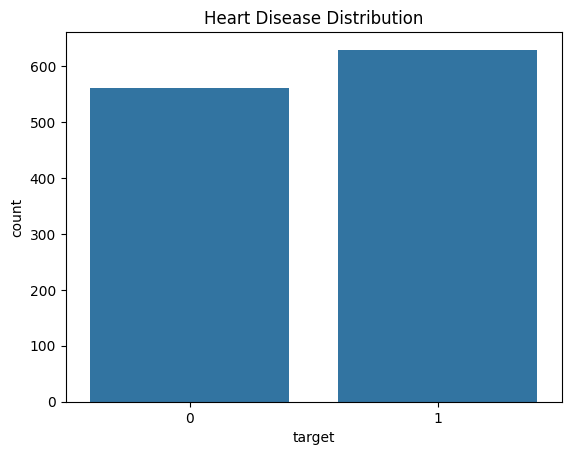

In [7]:
sns.countplot(x="target", data=df)
plt.title("Heart Disease Distribution")
plt.show()

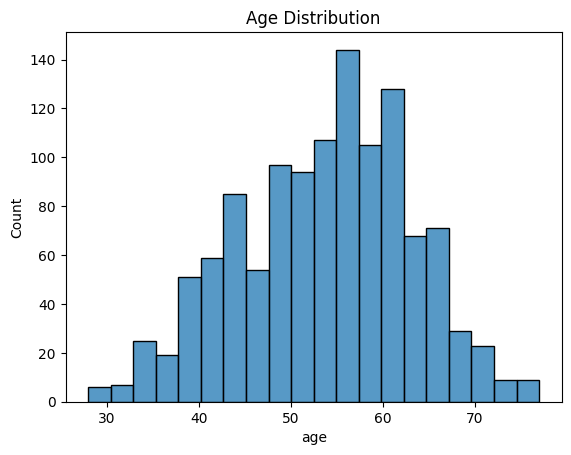

In [8]:
sns.histplot(df["age"], bins=20)
plt.title("Age Distribution")
plt.show()

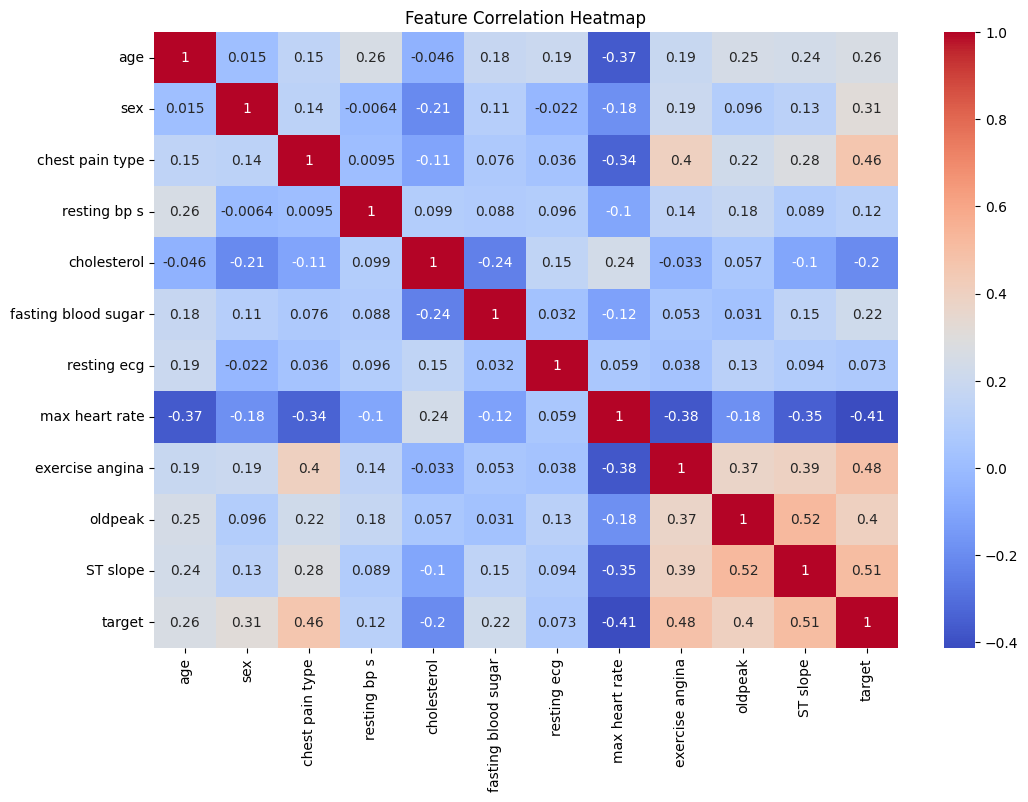

In [9]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [10]:
X = df.drop("target", axis=1)
y = df["target"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

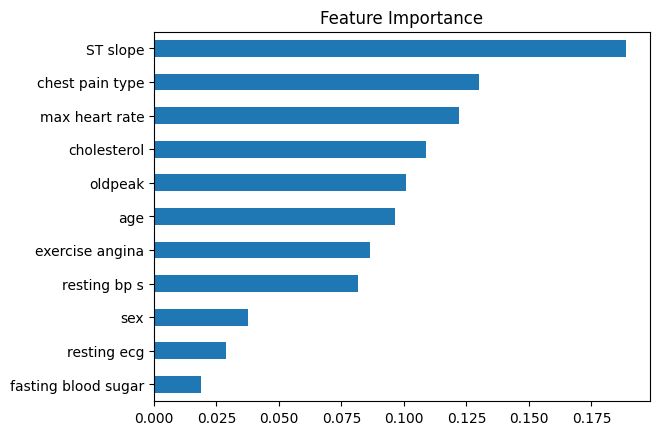

In [13]:
rf_temp = RandomForestClassifier()
rf_temp.fit(X_train, y_train)
importances = rf_temp.feature_importances_
importance_df = pd.Series(importances, index=X.columns)
importance_df.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()

In [14]:
selector = SelectKBest(score_func=f_classif, k=8)
X_new = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()]
print("Selected Features:", selected_features)

Selected Features: Index(['age', 'sex', 'chest pain type', 'fasting blood sugar',
       'max heart rate', 'exercise angina', 'oldpeak', 'ST slope'],
      dtype='object')


In [15]:
model = LogisticRegression(max_iter=1000)
rfe = RFE(model, n_features_to_select=8)
rfe.fit(X_train_scaled, y_train)
rfe_features = X.columns[rfe.support_]
print("RFE Features : ",rfe_features)

RFE Features :  Index(['age', 'sex', 'chest pain type', 'fasting blood sugar',
       'max heart rate', 'exercise angina', 'oldpeak', 'ST slope'],
      dtype='object')


In [16]:
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

In [17]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [18]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Logistic Regression Accuracy: 0.8613445378151261
Random Forest Accuracy: 0.9537815126050421


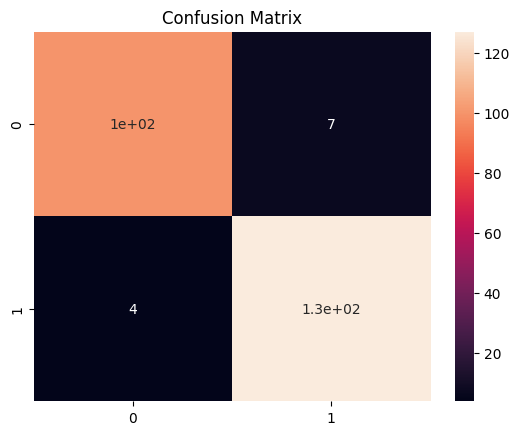

In [19]:
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True)
plt.title("Confusion Matrix")
plt.show()

In [20]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.96      0.93      0.95       107
           1       0.95      0.97      0.96       131

    accuracy                           0.95       238
   macro avg       0.95      0.95      0.95       238
weighted avg       0.95      0.95      0.95       238



In [21]:
param_grid = {
    "n_estimators":[100,200],
    "max_depth":[4,6,8],
    "min_samples_split":[2,5]
}
grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)
print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 8, 'min_samples_split': 2, 'n_estimators': 100}


In [22]:
best_model = grid.best_estimator_
pred = best_model.predict(X_test)
print("Optimized Accuracy:", accuracy_score(y_test, pred))

Optimized Accuracy: 0.9369747899159664


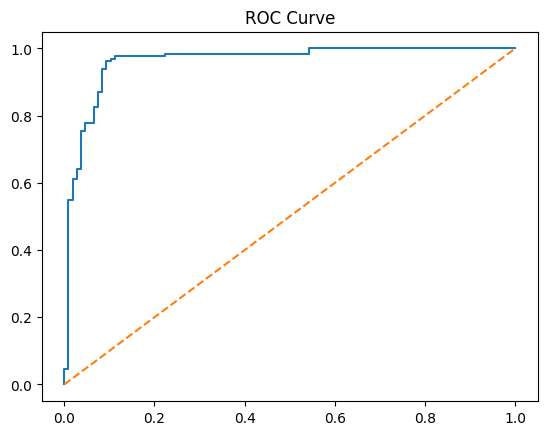

In [23]:
probs = best_model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],"--")
plt.title("ROC Curve")
plt.show()

In [24]:
def validate_input(value, min_val, max_val, name):
    try:
        value = float(value)
        if value < min_val or value > max_val:
            raise ValueError
        return value
    except:
        print(f"Invalid value for {name}. Enter value between {min_val} and {max_val}")
        return None

In [25]:
def get_user_input():
    print("Enter Patient Medical Information")
    age = validate_input(input("Age (20-100): "),20,100,"Age")
    sex = validate_input(input("Sex (0=Female,1=Male): "),0,1,"Sex")
    cp = validate_input(input("Chest Pain Type (0-3): "),0,3,"Chest Pain")
    trestbps = validate_input(input("Resting BP (80-200): "),80,200,"BP")
    chol = validate_input(input("Cholesterol (100-600): "),100,600,"Cholesterol")
    fbs = validate_input(input("Fasting Blood Sugar (0/1): "),0,1,"FBS")
    restecg = validate_input(input("Rest ECG (0-2): "),0,2,"ECG")
    thalach = validate_input(input("Max Heart Rate (60-220): "),60,220,"Heart Rate")
    exang = validate_input(input("Exercise Angina (0/1): "),0,1,"Angina")
    oldpeak = validate_input(input("Oldpeak (0-6): "),0,6,"Oldpeak")
    slope = validate_input(input("Slope (0-2): "),0,2,"Slope")
    inputs = [age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope]

    if None in inputs:
        print("Invalid inputs detected.")
        return None

    return inputs

In [26]:
def predict_heart_disease(data):
    data = np.array(data).reshape(1,-1)
    prediction = best_model.predict(data)
    probability = best_model.predict_proba(data)
    disease_prob = probability[0][1] * 100
    print("\nPrediction Result")
    if prediction[0] == 1:
        print(f"Heart Disease Likely ({disease_prob:.2f}% probability)")
    else:
        print(f"No Heart Disease Detected ({disease_prob:.2f}% risk)")

In [59]:
def run_prediction():
    user_data = get_user_input()
    if user_data is not None:
        predict_heart_disease(user_data)

In [60]:
run_prediction()

Enter Patient Medical Information
Age (20-100): 25
Sex (0=Female,1=Male): 0
Chest Pain Type (0-3): 2
Resting BP (80-200): 139
Cholesterol (100-600): 290
Fasting Blood Sugar (0/1): 1
Rest ECG (0-2): 2
Max Heart Rate (60-220): 150
Exercise Angina (0/1): 1
Oldpeak (0-6): 4
Slope (0-2): 1

Prediction Result
No Heart Disease Detected (38.26% risk)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [27]:
best_model = grid.best_estimator_

In [28]:
import joblib

joblib.dump(best_model, "heart_disease_model.pkl")

['heart_disease_model.pkl']

In [30]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [31]:
import joblib

model = joblib.load("heart_disease_model.pkl")
scaler = joblib.load("scaler.pkl")

In [32]:
def validate_input(value, min_val, max_val, name):

    try:
        value = float(value)

        if value < min_val or value > max_val:
            raise ValueError

        return value

    except:
        print(f"Invalid value for {name}. Please enter between {min_val} and {max_val}.")
        return None

In [40]:
def get_user_input():
    print("\nEnter Patient Medical Information\n")
    age = validate_input(input("Age (20-100): "),20,100,"Age")
    sex = validate_input(input("Sex (0=Female,1=Male): "),0,1,"Sex")
    cp = validate_input(input("Chest Pain Type (0-3): "),0,3,"Chest Pain Type")
    trestbps = validate_input(input("Resting Blood Pressure (80-200): "),80,200,"Resting BP")
    chol = validate_input(input("Cholesterol (100-600): "),100,600,"Cholesterol")
    fbs = validate_input(input("Fasting Blood Sugar (0 or 1): "),0,1,"FBS")
    restecg = validate_input(input("Rest ECG (0-2): "),0,2,"Rest ECG")
    thalach = validate_input(input("Max Heart Rate (60-220): "),60,220,"Max Heart Rate")
    exang = validate_input(input("Exercise Induced Angina (0 or 1): "),0,1,"Exang")
    oldpeak = validate_input(input("ST Depression (0-6): "),0,6,"Oldpeak")
    slope = validate_input(input("Slope (0-2): "),0,2,"Slope")
    inputs = [
        age,sex,cp,trestbps,chol,fbs,restecg,
        thalach,exang,oldpeak,slope
    ]
    if None in inputs:
        print("\nInvalid inputs detected. Please restart and try again.")
        return None

    return inputs

In [41]:
def predict_disease(user_data):
    data = np.array(user_data).reshape(1,-1)
    data_scaled = scaler.transform(data)
    prediction = model.predict(data_scaled)
    probability = model.predict_proba(data_scaled)
    disease_prob = probability[0][1] * 100

    print("\n----------------------------------")
    print("Heart Disease Prediction Result")
    print("----------------------------------")
    if prediction[0] == 1:
        print("Result: Heart Disease Likely")
    else:
        print("Result: No Heart Disease Detected")
    print(f"Probability of Heart Disease: {disease_prob:.2f}%")
    if disease_prob < 30:
        print("Risk Level: LOW")
    elif disease_prob < 60:
        print("Risk Level: MODERATE")
    else:
        print("Risk Level: HIGH")

In [42]:
def main():
    user_data = get_user_input()
    if user_data is not None:
        predict_disease(user_data)
if __name__ == "__main__":
    main()


Enter Patient Medical Information

Age (20-100): 23
Sex (0=Female,1=Male): 1
Chest Pain Type (0-3): 3
Resting Blood Pressure (80-200): 150
Cholesterol (100-600): 290
Fasting Blood Sugar (0 or 1): 1
Rest ECG (0-2): 2
Max Heart Rate (60-220): 130
Exercise Induced Angina (0 or 1): 1
ST Depression (0-6): 3
Slope (0-2): 2

----------------------------------
Heart Disease Prediction Result
----------------------------------
Result: Heart Disease Likely
Probability of Heart Disease: 70.00%
Risk Level: HIGH


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
